# "Ηλεκτρική Διασύνδεση Κρήτης - Πελοποννήσου"

Άσκηση για να εφαρμόσεις το LOPF είναι το σενάριο "Ηλεκτρική Διασύνδεση Κρήτης - Πελοποννήσου". Είναι το τέλειο παράδειγμα γιατί συνδέει μια περιοχή με φθηνή παραγωγή (ΑΠΕ στην Κρήτη) με ένα μεγάλο κέντρο κατανάλωσης, αλλά με περιορισμό στη χωρητικότητα του καλωδίου.

Φαντάσου δύο κόμβους: την Κρήτη και την Πελοπόννησο.

- Κρήτη: Έχει τεράστιο αιολικό δυναμικό (πολύ φθηνή ενέργεια), αλλά μικρή τοπική ζήτηση.
- Πελοπόννησος: Έχει μεγάλη ζήτηση και ακριβότερες μονάδες βάσης (π.χ. φυσικό αέριο).
- Καλώδιο: Μια γραμμή LOPF που συνδέει τους δύο κόμβους με συγκεκριμένο όριο (MW).

In [9]:
#ΟΡΙΣΜΟΣ ΤΟΥ ΔΙΚΥΟΥ
import pypsa
import pandas as pd

n = pypsa.Network()
n.set_snapshots(pd.date_range("2026-01-01 00:00", "2026-01-01 23:00", freq="h"))

# Προσθήκη Κόμβων
n.add("Bus", "Crete", x=24.0, y=35.0)
n.add("Bus", "Peloponnese", x=22.0, y=37.5)

# Προσθήκη του υποθαλάσσιου καλωδίου (Line)
# s_nom = 500 MW (το όριο που θα ελέγξει το LOPF)
n.add("Line", "Interconnector", 
      bus0="Crete", bus1="Peloponnese", 
      x=0.01, s_nom=500)

In [10]:
#ΠΑΡΑΓΩΓΗ ΚΑΙ ΖΗΤΗΣΗ

# Φθηνή Αιολική ενέργεια στην Κρήτη
import numpy as np
wind_profile = np.abs(np.sin(np.linspace(0, np.pi, 24))) # Αυξομείωση ανέμου
n.add("Generator", "Crete_Wind", bus="Crete", 
      p_nom=1000, marginal_cost=0, p_max_pu=wind_profile)

# Ακριβή μονάδα στην Πελοπόννησο
n.add("Generator", "Pelo_Gas", bus="Peloponnese", 
      p_nom=1000, marginal_cost=50)

# Ζήτηση στην Πελοπόννησο (Σταθερή 800 MW)
n.add("Load", "Pelo_Load", bus="Peloponnese", p_set=800)

Index(['Crete', 'Peloponnese'], dtype='str', name='name')
Index(['Interconnector'], dtype='str', name='name')
Index(['Interconnector'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 72 primals, 192 duals
Objective: 4.80e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


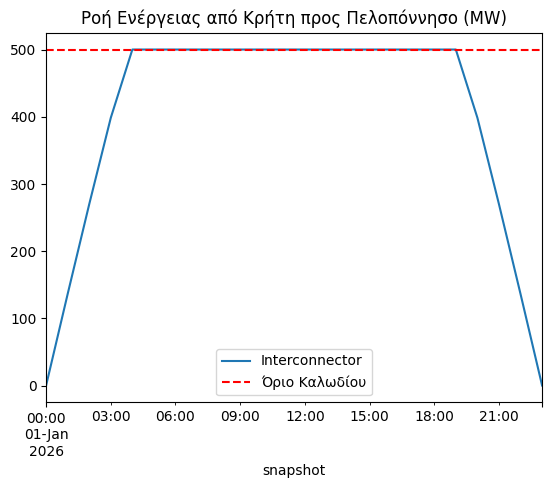

In [11]:
n.optimize(solver_name='highs')

# Έλεγχος: Πόση ενέργεια πέρασε από το καλώδιο;
import matplotlib.pyplot as plt
n.lines_t.p0.plot(title="Ροή Ενέργειας από Κρήτη προς Πελοπόννησο (MW)")
plt.axhline(y=500, color='r', linestyle='--', label='Όριο Καλωδίου')
plt.legend()
plt.show()

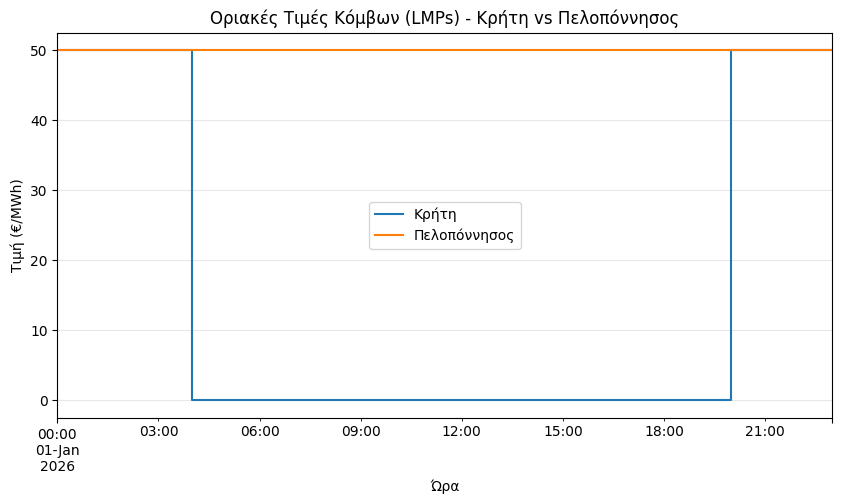

In [12]:
# Σχεδίαση των τιμών (Marginal Prices) για τους δύο κόμβους
n.buses_t.marginal_price.plot(drawstyle="steps-post", figsize=(10,5))
plt.title("Οριακές Τιμές Κόμβων (LMPs) - Κρήτη vs Πελοπόννησος")
plt.ylabel("Τιμή (€/MWh)")
plt.xlabel("Ώρα")
plt.grid(True, alpha=0.3)
plt.legend(["Κρήτη", "Πελοπόννησος"])


plt.show()

**Congestion (Συμφόρηση)**: 
- Τις ώρες που ο άνεμος στην Κρήτη είναι πολύς, η ροή θα "χτυπήσει" ακριβώς τα 500 MW. Το LOPF δεν θα αφήσει το καλώδιο να υπερφορτωθεί.

**Price Difference (Διαφορά Τιμής)**: 
- Όταν το καλώδιο δεν είναι γεμάτο, η τιμή στην Πελοπόννησο θα πέσει στα 0€ (γιατί παίρνει δωρεάν αέρα).

- Όταν το καλώδιο γεμίσει, η τιμή στην Πελοπόννησο θα ανέβει στα 50€, γιατί το LOPF αναγκάζεται να ανάψει το αέριο για να καλύψει το υπόλοιπο φορτίο.


- Σύγκλιση Τιμών (Price Convergence): Τις ώρες που η γραμμή έχει ελεύθερη χωρητικότητα, η "αγορά" είναι ενιαία. Η φθηνή ενέργεια της Κρήτης ρέει ελεύθερα και καθορίζει την τιμή και στην Πελοπόννησο.

- Απόκλιση Τιμών (Price Separation): Τις ώρες που το καλώδιο φτάνει τα 500 MW, η Πελοπόννησος δεν μπορεί να λάβει άλλη φθηνή ενέργεια. Η τιμή της "εκτοξεύεται" στα 50€ (το κόστος του αερίου), ενώ στην Κρήτη η τιμή παραμένει 0€ (γιατί εκεί περισσεύει ενέργεια που δεν μπορεί να εξαχθεί).

- Αξία της Επένδυσης: Η διαφορά των δύο τιμών (το "spread") δείχνει πόσα χρήματα χάνονται λόγω της αδυναμίας του δικτύου. Αν το spread είναι μεγάλο και συχνό, τότε η κατασκευή ενός δεύτερου καλωδίου είναι οικονομικά συμφέρουσα.


[<-- back](chapter4.md)